In [ ]:
!pip install --quiet pymupdf python-dotenv landingai-ade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.6/93.6 kB 4.8 MB/s eta 0:00:00


In [ ]:
import os
import json
import pymupdf
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
from IPython.display import display, IFrame, Markdown, HTML
from IPython.display import Image as DisplayImage
from PIL import Image as PILImage, ImageDraw


In [ ]:
from google.colab import userdata
import os

# Set the environment variable in the Colab session
os.environ["VISION_AGENT_API_KEY"] = userdata.get("VISION_AGENT_API_KEY")

# Now, the LandingAI library will automatically detect and use this environment variable
from landingai_ade import LandingAIADE
client = LandingAIADE()
print("Authenticated client initialized")

Authenticated client initialized


In [ ]:
from helper import print_document, draw_bounding_boxes, draw_bounding_boxes_2
from helper import create_cropped_chunk_images

In [ ]:
def display_directory(directory_path: str):
    """
    Displays all supported documents (PDFs and images) in a directory.

    Args:
        directory_path: Path to the directory containing the documents.
    """
    directory = Path(directory_path)

    if not directory.exists() or not directory.is_dir():
        print(f"Directory not found: {directory_path}")
        return

    # Supported extensions
    supported = {".png", ".jpg", ".jpeg", ".pdf"}

    # Get all matching files
    files = sorted([f for f in directory.iterdir()
                    if f.suffix.lower() in supported])

    if not files:
        print("No supported documents found.")
        return

    # Display each document using your existing helper
    for f in files:
        print(f"\n--- Displaying: {f.name} ---\n")
        print_document(str(f))

In [9]:
# Import Pydantic for schema definition
# ADE accepts pydantic and JSON schemas.
# Exercise 1 used JSON. Exercise 3 uses pydantic.

from enum import Enum
from pydantic import BaseModel, Field
from landingai_ade.lib import pydantic_to_json_schema

class DocumentType(str, Enum):
    ID = "ID"
    W2 = "W2"
    pay_stub = "pay_stub"
    bank_statement = "bank_statement"
    investment_statement = "investment_statement"

    # Descriptions for each value
    def describe(self) -> str:
        descriptions = {
            "ID": "An official government identification such as a "
            "passport or driver's license.",
            "W2": "A year-end W-2 form reporting annual taxable wages "
            "and withholdings.",
            "pay_stub": "A periodic employee earnings statement.",
            "bank_statement": "A checking or savings account statement "
            "with balances and transactions.",
            "investment_statement": "A brokerage or investment account "
            "statement showing holdings, value, and transactions.",
        }
        return descriptions[self.value]

class DocType(BaseModel):
    type: DocumentType = Field(
        description="The type of document being analyzed.",
        title="Document Type",
    )

In [10]:
# ---------------------------------------------------------
# Schema for ID
# ---------------------------------------------------------
class IDSchema(BaseModel):
    name: str = Field(description="Full name of the person",
                      title="Full Name")
    issuer: str = Field(description="The state or country issuing the "
                        "identification.", title="Issuer")
    issue_date: str = Field(description="The issue date for the "
                            "identification.", title="Issue Date")
    identifier: str = Field(description="The unique identifier such as a "
                            "drivers license number or passport number",
                            title="Identifier")

# ---------------------------------------------------------
# Schema for W2
# ---------------------------------------------------------
class W2Schema(BaseModel):
    employee_name: str = Field(description="The name of the employee.",
                               title="Employee Name")
    employer_name: str = Field(description="The name of the employer "
                               "organization issuing the W2.",
                               title="Employer Name")
    w2_year: int = Field(description="The year of the W2 form.",
                         title="W2 Year")
    wages_box_1: float = Field(description="The total wages shown in box 1 "
                               "of the form", title="Box 1")

# ---------------------------------------------------------
# Schema for Pay Stubs
# ---------------------------------------------------------
class PaymentStubSchema(BaseModel):
    employee_name: str = Field(description="The name of the employee.",
                               title="Employee Name")
    employer_name: str = Field(description="The name of the employer "
                               "organization.", title="Employer Name")
    pay_period: str = Field(description="The pay period for the stub.",
                            title="Pay Period")
    gross_pay: float = Field(description="The gross pay amount.",
                             title="Gross Pay")
    net_pay: float = Field(description="The net pay amount after "
                           "deductions.", title="Net Pay")

# ---------------------------------------------------------
# Schema for Bank Statements
# ---------------------------------------------------------
class BankStatementSchema(BaseModel):
    account_owner: str = Field(description="The name of the account "
                               "owner(s).", title="Account Owner")
    bank_name: str = Field(description="The name of the bank.",
                           title="Bank Name")
    account_number: str = Field(description="The bank account number.",
                                title="Account Number")
    end_date: str = Field(description="The ending date for the statement.",
                          title="End Date")
    balance: float = Field(description="The current balance of the bank "
                           "account.", title="Bank Balance")

# ---------------------------------------------------------
# Schema for Investment Statements
# ---------------------------------------------------------
class InvestmentStatementSchema(BaseModel):
    account_owner: str = Field(description="The name of the account owner(s)."
                               , title="Account Owner")
    institution_name: str = Field(description="The name of the financial "
                                  "institution.", title="Institution Name")
    investment_year: int = Field(description="The year of the investment "
                                 "statement.", title="Investment Year")
    investment_value: float = Field(description="The total value of the "
                                    "account as of the statement end date.",
                                    title="Investment Balance")

# ---------------------------------------------------------
# Map document types to their corresponding schemas
# ---------------------------------------------------------
schema_per_doc_type = {
    "bank_statement": BankStatementSchema,
    "investment_statement": InvestmentStatementSchema,
    "pay_stub": PaymentStubSchema,
    "ID": IDSchema,
    "W2": W2Schema,
}

In [11]:
# Convert the document type schema to JSON format for API calls
doc_type_json_schema = pydantic_to_json_schema(DocType)

In [13]:
# Imports specific to Agentic Document Extraction
from landingai_ade import LandingAIADE
from landingai_ade.types import ParseResponse, ExtractResponse

In [15]:
input_folder = Path("/content")

# Dictionary to store document types and parse results
document_types = {}

# Process each document in the folder
for document in input_folder.iterdir():

    # 🔥 Skip directories so ADE doesn't try to parse them
    if document.is_dir():
        continue

     # Supported extensions
    supported = {".png", ".jpg", ".jpeg", ".pdf"}

    if document.suffix.lower() not in supported:
        continue

    print(f"Processing document: {document.name}")

    # Step 1: Parse the document to extract layout and content
    parse_result: ParseResponse = client.parse(
        document=document,
        split="page",  #Notice that each document is being split by page.
        model="dpt-2-latest"
    )
    print("Parsing completed.")
    print(" ")

    # Notice that we only use the first page to determine the document type
    first_page_markdown = parse_result.splits[0].markdown

    # Step 2: Extract document type using the categorization schema
    print("Extracting Document Type...")
    extraction_result: ExtractResponse = client.extract(
        schema=doc_type_json_schema,
        markdown=first_page_markdown
    )
    doc_type = extraction_result.extraction["type"]
    print(f"Document Type Extraction: {doc_type}\n")
    print("       ----------         ")
    print(" ")

    # Store results for later use
    document_types[document] = {
        "document_type": doc_type,
        "parse_result": parse_result
    }

Processing document: uploadA.pdf
Parsing completed.
 
Extracting Document Type...
Document Type Extraction: investment_statement

       ----------         
 


In [16]:
# Dictionary to store extraction results
document_extractions = {}

# Extract financial data from each document using its specific schema
for document, extraction in document_types.items():
    print(f"Processing document: {document.name}")

    # Get the appropriate schema for this document type
    json_schema = pydantic_to_json_schema(
        schema_per_doc_type[extraction["document_type"]]
    )

    # Extract structured data using the schema
    extraction_result: ExtractResponse = client.extract(
        schema=json_schema,
        markdown=extraction["parse_result"].markdown
    )
    print("Detailed Extraction:", extraction_result.extraction)
    print("\n")
    print("Detailed Extraction:", extraction_result.extraction_metadata)

    # Store extraction results
    document_extractions[document] = {
        "extraction": extraction_result.extraction,
        "extraction_metadata": extraction_result.extraction_metadata,
    }

print(document_extractions)

Processing document: uploadA.pdf
Detailed Extraction: {'account_owner': 'John W. Doe', 'institution_name': 'Fidelity Investments', 'investment_year': 2015, 'investment_value': 274222.2}
{PosixPath('/content/uploadA.pdf'): {'extraction': {'account_owner': 'John W. Doe', 'institution_name': 'Fidelity Investments', 'investment_year': 2015, 'investment_value': 274222.2}, 'extraction_metadata': {'account_owner': {'value': 'John W. Doe', 'references': ['93ffcaf9-d114-444d-b957-d6ab46d18152']}, 'institution_name': {'value': 'Fidelity Investments', 'references': ['2d055921-c158-4fb4-b9f8-23e0cb6cb8b9']}, 'investment_year': {'value': 2015, 'references': ['2419409d-89b3-45e0-97ae-d0d3087518a7']}, 'investment_value': {'value': 274222.2, 'references': ['5c210b7f-548c-4362-87fa-2e96cd69daac', '0-l']}}}}


In [17]:
from helper import draw_bounding_boxes_2

# Combine all extraction data
final_extractions = {}

for document, extraction in document_extractions.items():
    final_extractions[document] = {
        **extraction,
        **document_types[document],
    }

# Visualize all parsed chunks for each document
for document, extraction in final_extractions.items():
    print(f"Visualizing document: {document.name}")
    base_path = f"results/{document.stem}"
    os.makedirs(base_path, exist_ok=True)
    draw_bounding_boxes_2(
        extraction["parse_result"].grounding,
        document,
        base_path=base_path
    )

Visualizing document: uploadA.pdf
Annotated image saved to: results/uploadA/page_1_annotated.png


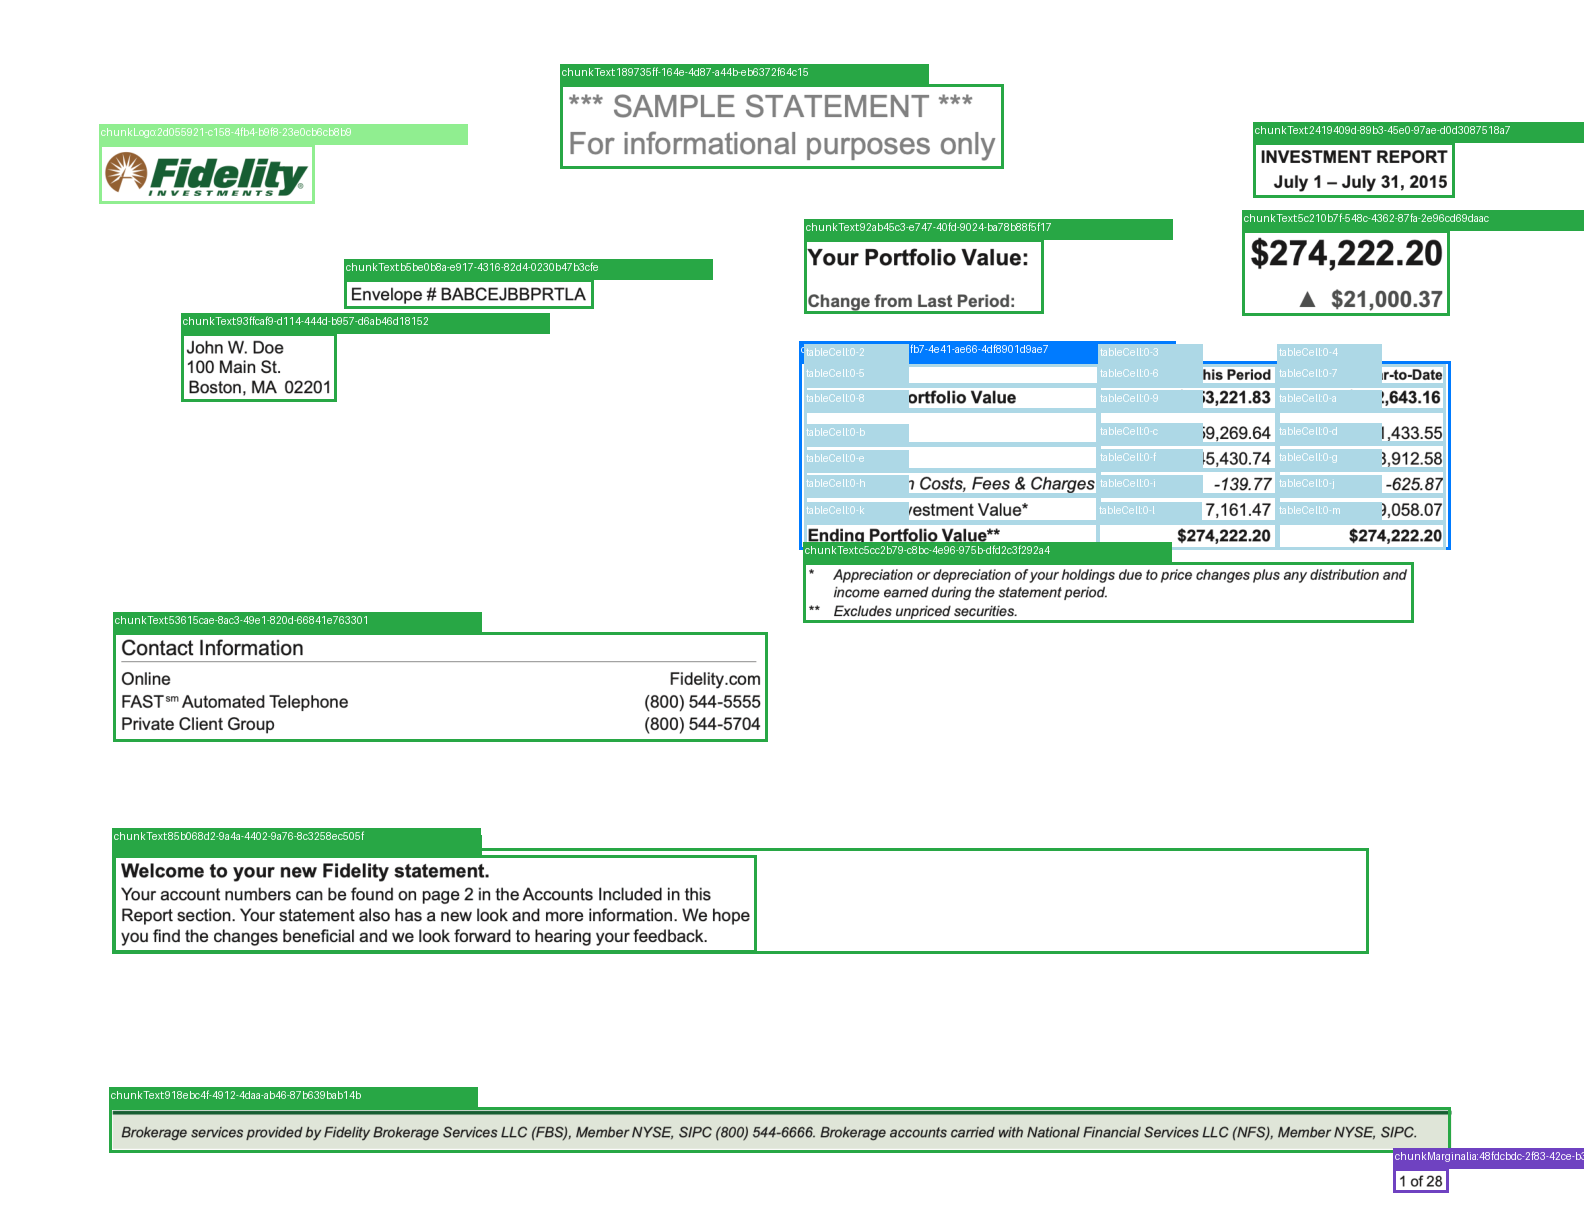

In [18]:
PILImage.open(f"results/uploadA/page_1_annotated.png")

In [44]:
for document, extraction in final_extractions.items():
    print(f"Visualizing extracted fields for: {document.name}")
    base_path = f"/results_extracted/{document.stem}"
    os.makedirs(base_path, exist_ok=True)
    parse_result = extraction["parse_result"]
    document_grounds = {}

    for label, metadata_value in extraction["extraction_metadata"].items():
        chunk_id = metadata_value["references"][0]
        grounding = parse_result.grounding[chunk_id]
        document_grounds[chunk_id] = grounding

    print("done till here")

    draw_bounding_boxes_2(
        document_grounds,  # dict of chunk_id -> grounding
        document,
        base_path=base_path
    )

Visualizing extracted fields for: uploadA.pdf
done till here
Annotated image saved to: /results_extracted/uploadA/page_1_annotated.png


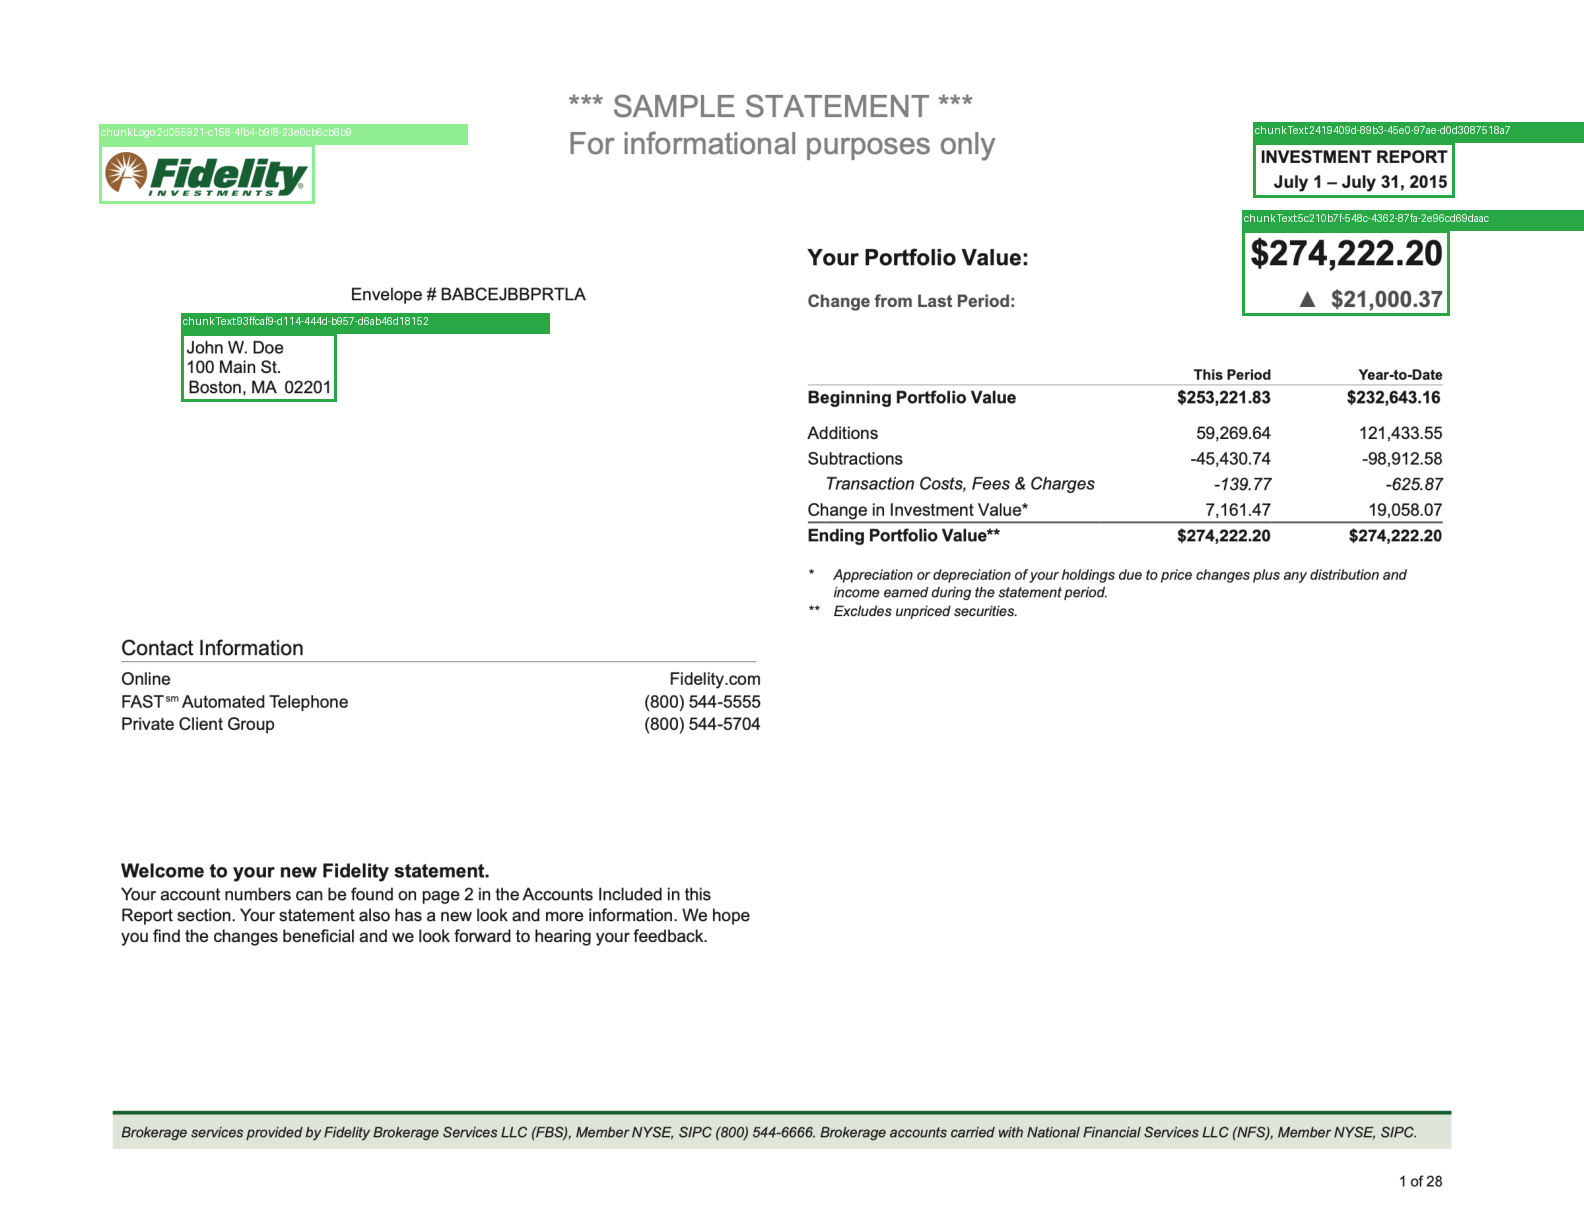

In [45]:
PILImage.open(f"content/results_extracted/uploadA/page_1_annotated.png")

In [46]:
import pandas as pd

# Collect all the fields into a summary dataframe
rows = []

for document, info in document_extractions.items():
    extraction = info["extraction"]
    doc_type = document_types[document]["document_type"]  # from your classification step

    input_folder = document.parent.name
    document_name = document.name

    for field, value in extraction.items():
        rows.append({
            "applicant_folder": input_folder,
            "document_name": document_name,
            "document_type": doc_type,
            "field": field,
            "value": value,
        })

df = pd.DataFrame(rows)

df

,applicant_folder,document_name,document_type,field,value
0,content,uploadA.pdf,investment_statement,account_owner,John W. Doe
1,content,uploadA.pdf,investment_statement,institution_name,Fidelity Investments
2,content,uploadA.pdf,investment_statement,investment_year,2015
3,content,uploadA.pdf,investment_statement,investment_value,274222.2


In [47]:
# Logic to extract and check the year associated with each document

import re

# 1. Fields that may contain a year
year_fields = {
    "w2_year",
    "investment_year",
    "issue_date",
    "end_date",
    "pay_period",
}

# 2. Helper to pull a 4-digit year out of a string/number
def extract_year(value):
    """
    Return a 4-digit year (1900–2099) from a value, or None if none found.
    """
    if value is None:
        return None
    match = re.search(r"\b(19|20)\d{2}\b", str(value))
    return int(match.group(0)) if match else None


# 3. Build a table of years per document
year_rows = []

for doc_name in df["document_name"].unique():
    doc_df = df[df["document_name"] == doc_name]

    # Only rows whose field is one of our year-related fields
    doc_year_fields = doc_df[doc_df["field"].isin(year_fields)]

    for _, row in doc_year_fields.iterrows():
        year_value = extract_year(row["value"])
        year_rows.append({
            "document_name": doc_name,
            "field": row["field"],
            "value": row["value"],
            "year_extracted": year_value,
        })

df_years = pd.DataFrame(year_rows)

print("Per-document year info:")
print(df_years)

Per-document year info:
  document_name            field  value  year_extracted
0   uploadA.pdf  investment_year   2015            2015


In [48]:
print(df)

<bound method NDFrame.head of   applicant_folder document_name         document_type             field  \
0          content   uploadA.pdf  investment_statement     account_owner   
1          content   uploadA.pdf  investment_statement  institution_name   
2          content   uploadA.pdf  investment_statement   investment_year   
3          content   uploadA.pdf  investment_statement  investment_value   

                  value  
0           John W. Doe  
1  Fidelity Investments  
2                  2015  
3              274222.2  >


In [49]:
# Logic to sum all bank balances and all investment balances from your extraction

# Define fields
bank_balance_field = "balance"
investment_balance_field = "investment_value"

# Filter rows
df_bank = df[df["field"] == bank_balance_field].copy()
df_invest = df[df["field"] == investment_balance_field].copy()

# Ensure numeric
df_bank["value"] = pd.to_numeric(df_bank["value"], errors="coerce")
df_invest["value"] = pd.to_numeric(df_invest["value"], errors="coerce")

# Compute totals
total_bank = df_bank["value"].sum()
total_investments = df_invest["value"].sum()
total_assets = total_bank + total_investments

# Print
print(f"Total Bank Balances: ${total_bank:,.2f}")
print(f"Total Investment Balances: ${total_investments:,.2f}")
print(f"Total Assets: ${total_assets:,.2f}")

Total Bank Balances: $0.00
Total Investment Balances: $274,222.20
Total Assets: $274,222.20
